## **Market Basket Analysis Using Apriori Algorithm**

### 🧾 Step 1: Import Libraries & Load Dataset

In [ ]:
!pip install mlxtend #installs the mlxtend library
import pandas as pd #import dataframe
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

telco = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv') #load dataset
telco.columns = telco.columns.str.strip() #clean column names

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

> Setup and Data Loading

- Installed `mlxtend` for Apriori algorithm
- Imported required libraries
- Loaded Telco dataset and cleaned column names

### 🧹 Step 2: Data Cleaning for Apriori

In [ ]:
#convert 'TotalCharges' to numeric and drop missing
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco.dropna(subset=['TotalCharges'], inplace=True)

#drop customerID
telco.drop('customerID', axis=1, inplace=True)

#one-hot encode all categorical columns (keep all dummies)
telco = pd.get_dummies(telco, drop_first=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

> Data Preprocessing for Apriori

- Converted `TotalCharges` to numeric and dropped missing values
- Removed `customerID` (non-predictive)
- One-hot encoded all categorical variables (no `drop_first`) to preserve all item labels for Apriori


### 📊 Step 3: Create Basket of Services

In [ ]:
#choose service features for Apriori
apriori_cols = [
    'PhoneService_Yes',
    'MultipleLines_Yes',
    'InternetService_DSL',
    'InternetService_Fiber optic',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

#create basket: binary matrix
service_basket = telco[apriori_cols].astype(int)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

> Prepare Basket Data for Apriori

- Selected only service-related features
- Converted values to binary (1 = subscribed, 0 = not)
- Created a customer × service matrix for Apriori analysis

### 🔍 Step 4: Apply Apriori & Generate Rules

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

#generate frequent itemsets
frequent_itemsets = apriori(service_basket, min_support=0.1, use_colnames=True)

#create rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)

#sort by lift and keep top 10
top10_rules = rules.sort_values(by='lift', ascending=False).head(10)

#convert frozensets to string for readability
top10_rules['antecedents'] = top10_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top10_rules['consequents'] = top10_rules['consequents'].apply(lambda x: ', '.join(list(x)))

#display top 10 rules
print(top10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

                                            antecedents  \
1011             MultipleLines_Yes, StreamingMovies_Yes   
994   StreamingTV_Yes, PhoneService_Yes, DeviceProte...   
998   PhoneService_Yes, DeviceProtection_Yes, Stream...   
1007                 StreamingTV_Yes, MultipleLines_Yes   
859               StreamingTV_Yes, DeviceProtection_Yes   
862                TechSupport_Yes, StreamingMovies_Yes   
863           DeviceProtection_Yes, StreamingMovies_Yes   
858                    StreamingTV_Yes, TechSupport_Yes   
973                  StreamingTV_Yes, MultipleLines_Yes   
972   OnlineBackup_Yes, PhoneService_Yes, StreamingM...   

                                            consequents   support  confidence  \
1011  StreamingTV_Yes, PhoneService_Yes, DeviceProte...  0.117321    0.518542   
994              MultipleLines_Yes, StreamingMovies_Yes  0.117321    0.591822   
998                  StreamingTV_Yes, MultipleLines_Yes  0.117321    0.585938   
1007  PhoneService_Yes, De

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

> Apriori Results – Top Association Rules
- Example Rule:
  - **If** a customer has: `MultipleLines + StreamingMovies`
  - **Then** they likely also have: `PhoneService + DeviceProtection + StreamingTV`
- Support: 11.7%
- Confidence: 51.9%
- Lift: 2.61

> Business Insight:
- Strong candidates for bundling
- Telco can promote these service combos to increase retention and upsell


### 📈 Step 5: Visualize Top Rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

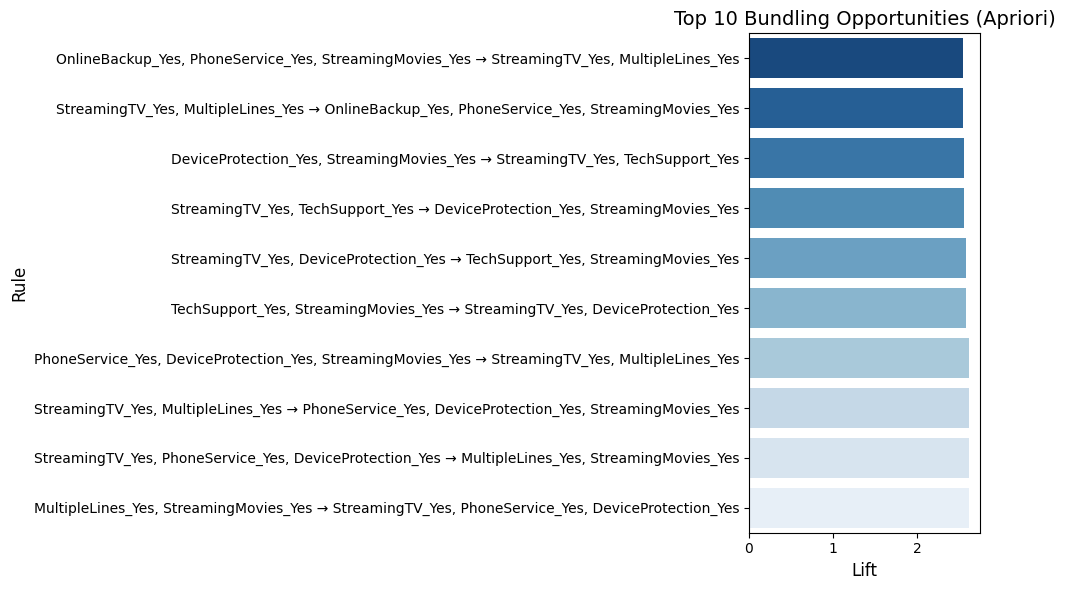

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
top10_rules_sorted = top10_rules.sort_values(by='lift', ascending=True)

# Step 1: Create a cleaner label for each rule
top10_rules_sorted['rule_label'] = top10_rules_sorted['antecedents'].astype(str) + " → " + top10_rules_sorted['consequents'].astype(str)

# Step 2: Sort by lift for plotting
top10_rules_sorted = top10_rules_sorted.sort_values(by='lift', ascending=True)

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='lift',
    y='rule_label',
    data=top10_rules_sorted,
    palette='Blues_r'
)
plt.title("Top 10 Bundling Opportunities (Apriori)", fontsize=14)
plt.xlabel("Lift", fontsize=12)
plt.ylabel("Rule", fontsize=12)
plt.tight_layout()
plt.show()

| Column        | Meaning                                                                                | Good Value ✅                                      | Weak/Bad Value ⚠️                                |
| ------------- | -------------------------------------------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------ |
| `antecedents` | The “**IF**” part — services the customer already has                                  | — (based on selected features)                    | —                                                |
| `consequents` | The “**THEN**” part — what services often appear **together** with antecedents         | —                                                 | —                                                |
| `support`     | How **frequent** this full combination (antecedents + consequents) appears in the data | ✅ **Above 0.05** (≥ 5%) → enough coverage         | ⚠️ **Below 0.01** (< 1%) → too rare / not useful |
| `confidence`  | Chance of getting the consequent **if** the antecedent exists                          | ✅ **Above 0.6** (≥ 60%) → strong conditional rule | ⚠️ **Below 0.3** (< 30%) → weak correlation      |
| `lift`        | How much **more likely** the rule happens **vs random chance**                         | ✅ **Above 1.5** → strong relationship             | ⚠️ **≤ 1.0** → not better than random guess      |


| Metric     | ✅ Good Value | ❌ Avoid if…                |
| ---------- | ------------ | -------------------------- |
| Support    | > 0.05 (5%)  | < 0.01 (1%)                |
| Confidence | > 0.50 (50%) | < 0.30 (30%)               |
| Lift       | > 1.5        | ≤ 1.0 (means no real link) |
